In [1]:
# %% 데이터 로드
import glob, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# seaborn 스타일을 먼저 적용 (이게 폰트를 덮어쓸 수 있어서 순서 중요!)
sns.set_style('whitegrid')

# 그 다음 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 출력 옵션
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)
 
from pathlib import Path
 
current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent
 
# ── 추정매출 로드 (기존 코드 재사용) ──
DATA_DIR = str(project_root / 'data' / 'extracted' / '서울시_상권분석서비스(추정매출+영역)') + '/'
pattern = DATA_DIR + '*추정매출*.csv'
sales_files = sorted(glob.glob(pattern))
print(f'추정매출 파일: {len(sales_files)}개')
 
sales = pd.concat(
    [pd.read_csv(f, encoding='cp949', low_memory=False) for f in sales_files],
    ignore_index=True
)
print(f'  → 통합: {sales.shape[0]:,}행 × {sales.shape[1]}컬럼')
 
# ── 영역 로드 ──
area_path = glob.glob(DATA_DIR + '*영역*상권*.csv')[0]
area = pd.read_csv(area_path, encoding='cp949')
print(f'영역: {area.shape[0]:,}개 상권')
 
# ── 길단위인구(유동인구) 로드 ──
floating_path = project_root / 'data' / 'extracted' / '서울시 상권분석서비스(길단위인구-상권)' / '서울시 상권분석서비스(길단위인구-상권).csv'
floating = pd.read_csv(floating_path, encoding='cp949')
print(f'유동인구: {floating.shape[0]:,}행 × {floating.shape[1]}컬럼')
 
# ── 직장인구 로드 ──
work_path = project_root / 'data' / '06_직장인구' / '서울시 상권분석서비스(직장인구-상권).csv'
df_직장 = pd.read_csv(work_path, encoding='cp949')
print(f'직장인구: {df_직장.shape[0]:,}행 × {df_직장.shape[1]}컬럼')
 
# ── 상주인구 로드 ──
resident_path = project_root / 'data' / '07_상주인구' / '서울시 상권분석서비스(상주인구-상권).csv'
df_상주 = pd.read_csv(resident_path, encoding='cp949')
print(f'상주인구: {df_상주.shape[0]:,}행 × {df_상주.shape[1]}컬럼')
 
print('\n✅ 전체 데이터 로드 완료')

추정매출 파일: 6개
  → 통합: 519,931행 × 55컬럼
영역: 1,650개 상권
유동인구: 46,184행 × 27컬럼
직장인구: 45,840행 × 26컬럼
상주인구: 40,812행 × 29컬럼

✅ 전체 데이터 로드 완료


In [2]:
# %% 컬럼 정의 및 데이터 준비
상권 = ['골목상권', '발달상권', '관광특구', '전통시장']
타겟업종 = ['커피-음료', '호프-간이주점', '화장품']

In [3]:
# ── 유동인구: 20~30대 비율 계산 ──
floating['2030_유동'] = floating['연령대_20_유동인구_수'] + floating['연령대_30_유동인구_수']
floating['2030_비율'] = floating['2030_유동'] / floating['총_유동인구_수'].replace(0, np.nan) * 100

In [5]:
# ── 상권별 전체 매출 + 타겟 업종별 매출 ──
전체매출 = sales.groupby(
    ['기준_년분기_코드', '상권_코드', '상권_구분_코드_명']
)['당월_매출_금액'].sum().reset_index()
전체매출.rename(columns={'당월_매출_금액': '전체_매출'}, inplace=True)
 
for 업종 in 타겟업종:
    sub = sales[sales['서비스_업종_코드_명'] == 업종].groupby(
        ['기준_년분기_코드', '상권_코드']
    )['당월_매출_금액'].sum().reset_index()
    sub.rename(columns={'당월_매출_금액': f'{업종}_매출'}, inplace=True)
    전체매출 = 전체매출.merge(sub, on=['기준_년분기_코드', '상권_코드'], how='left')
 
전체매출 = 전체매출.fillna(0)
전체매출

,기준_년분기_코드,상권_코드,상권_구분_코드_명,전체_매출,커피-음료_매출,호프-간이주점_매출,화장품_매출
0,20201,3001491,관광특구,74502776375,"4,514,073,090.00","4,507,140,105.00","6,925,657,567.00"
1,20201,3001492,관광특구,258220349357,"9,844,001,301.00","3,062,234,904.00","39,865,950,196.00"
2,20201,3001493,관광특구,85952314939,"841,880,163.00","644,074,613.00","12,005,627,374.00"
3,20201,3001494,관광특구,205986547708,"3,554,967,917.00","5,269,408,968.00","2,151,458,975.00"
4,20201,3001495,관광특구,171703093189,"4,300,450,049.00","3,140,147,663.00","7,235,870,455.00"
...,...,...,...,...,...,...,...
37653,20254,3130323,전통시장,14312819445,"4,830,571.00","391,531,991.00","22,167,856.00"
37654,20254,3130324,전통시장,7415216657,"17,817,384.00",0.00,0.00
37655,20254,3130325,전통시장,3680810022,0.00,0.00,0.00
37656,20254,3130326,전통시장,15616098774,0.00,"155,944,404.00",0.00


In [6]:
# ── 비중 계산 ──
for 업종 in 타겟업종:
    전체매출[f'{업종}_비중'] = 전체매출[f'{업종}_매출'] / 전체매출['전체_매출'] * 100
 
전체매출['타겟3_비중'] = (
    전체매출['커피-음료_매출'] + 전체매출['호프-간이주점_매출'] + 전체매출['화장품_매출']
) / 전체매출['전체_매출'] * 100
 
# ── 유동인구 merge ──
merged_age = 전체매출.merge(
    floating[['기준_년분기_코드', '상권_코드', '2030_비율', '총_유동인구_수']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)

In [8]:
# %% 상관계수 분석
print('📊 상권구분별 20~30대 유동인구 비율 vs 커피·주점·화장품')
print('-' * 75)
print(f'{"유형":<10} {"2030비율":>8} {"커피":>8} {"주점":>8} {"화장품":>8} {"3업종합":>8} {"상관계수":>10}')
print('-' * 75)
for 구분 in 상권:
    sub = merged_age[merged_age['상권_구분_코드_명'] == 구분]
    corr = sub[['2030_비율', '타겟3_비중']].corr().iloc[0, 1]
    print(f'{구분:<10} {sub["2030_비율"].mean():>7.1f}%'
          f' {sub["커피-음료_비중"].mean():>7.1f}%'
          f' {sub["호프-간이주점_비중"].mean():>7.1f}%'
          f' {sub["화장품_비중"].mean():>7.1f}%'
          f' {sub["타겟3_비중"].mean():>7.1f}%'
          f' {corr:>9.3f}')

📊 상권구분별 20~30대 유동인구 비율 vs 커피·주점·화장품
---------------------------------------------------------------------------
유형           2030비율       커피       주점      화장품     3업종합       상관계수
---------------------------------------------------------------------------
골목상권          32.4%     4.6%     3.1%     1.2%     9.0%     0.162
발달상권          38.3%     4.6%     3.5%     2.5%    10.6%     0.319
관광특구          44.2%     3.5%     3.7%     4.5%    11.6%     0.479
전통시장          33.0%     1.6%     2.9%     0.9%     5.5%     0.276


In [9]:
# %% 2030 비율 5분위별 분석
merged_age['2030_구간'], bins = pd.qcut(
    merged_age['2030_비율'].dropna(), q=5, retbins=True, duplicates='drop'
)
라벨 = [f'{bins[i]:.0f}~{bins[i+1]:.0f}%' for i in range(len(bins)-2)]
라벨.append(f'{bins[-2]:.0f}% 이상')
merged_age['2030_구간'] = pd.qcut(
    merged_age['2030_비율'].dropna(), q=5, labels=라벨, duplicates='drop'
)
 
구간별 = merged_age.groupby('2030_구간').agg(
    평균2030=('2030_비율', 'mean'),
    커피=('커피-음료_비중', 'mean'),
    주점=('호프-간이주점_비중', 'mean'),
    화장품=('화장품_비중', 'mean'),
    합계=('타겟3_비중', 'mean'),
    n=('상권_코드', 'count')
).reset_index()

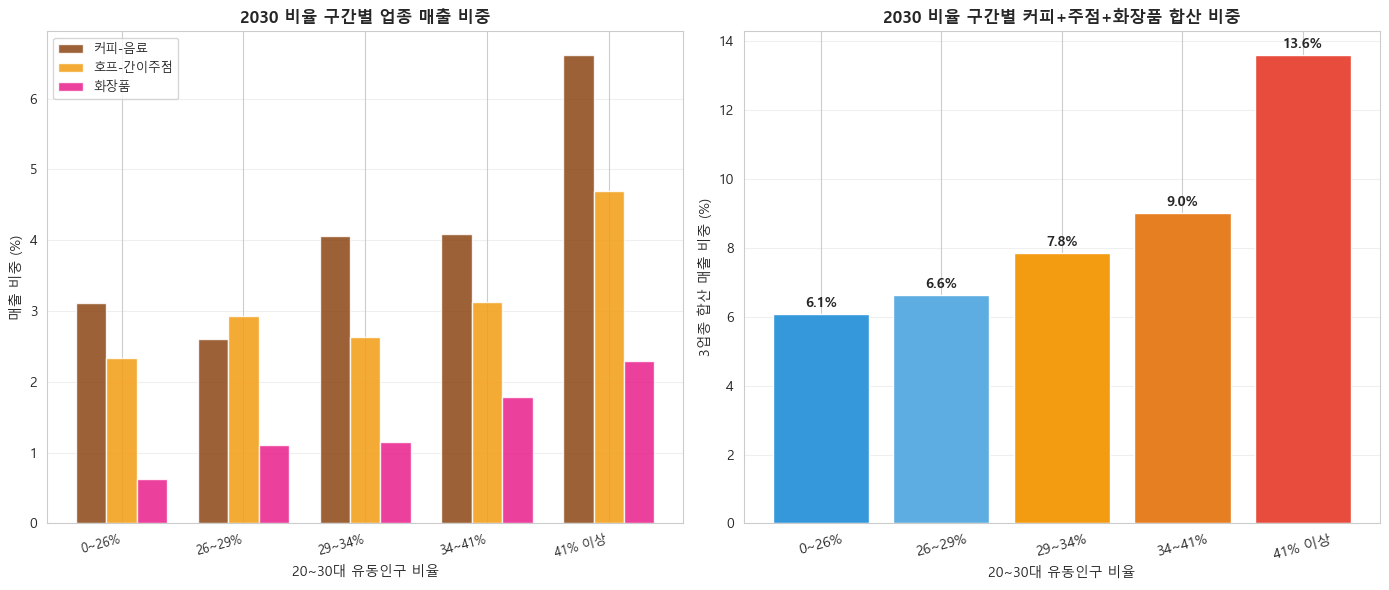

In [10]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# (1) 업종별 분리
ax1 = axes[0]
x = np.arange(len(구간별))
w = 0.25
ax1.bar(x - w, 구간별['커피'], w, color='#8B4513', alpha=0.85, label='커피-음료')
ax1.bar(x, 구간별['주점'], w, color='#F39C12', alpha=0.85, label='호프-간이주점')
ax1.bar(x + w, 구간별['화장품'], w, color='#E91E8C', alpha=0.85, label='화장품')
ax1.set_xticks(x)
ax1.set_xticklabels(구간별['2030_구간'], fontsize=9, rotation=15, ha='right')
ax1.set_ylabel('매출 비중 (%)')
ax1.set_xlabel('20~30대 유동인구 비율')
ax1.set_title('2030 비율 구간별 업종 매출 비중', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
 
# (2) 3업종 합산
ax2 = axes[1]
colors = ['#3498DB', '#5DADE2', '#F39C12', '#E67E22', '#E74C3C']
bars = ax2.bar(구간별['2030_구간'], 구간별['합계'], color=colors, edgecolor='white')
ax2.set_ylabel('3업종 합산 매출 비중 (%)')
ax2.set_xlabel('20~30대 유동인구 비율')
ax2.set_title('2030 비율 구간별 커피+주점+화장품 합산 비중', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=15)
 
for bar, val in zip(bars, 구간별['합계']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
 
plt.tight_layout()
plt.show()

In [11]:
# %% 업종 간 상관관계 + 상권 유형 비교
corr_3 = merged_age[['커피-음료_비중', '호프-간이주점_비중', '화장품_비중']].corr()
 
print('📊 3업종 간 상관관계')
print(corr_3.round(3))
 
# 커피 상위 vs 주점 상위 상권 프로필 비교
커피_상위 = merged_age[merged_age['커피-음료_비중'] > merged_age['커피-음료_비중'].quantile(0.8)]
주점_상위 = merged_age[merged_age['호프-간이주점_비중'] > merged_age['호프-간이주점_비중'].quantile(0.8)]
화장_상위 = merged_age[merged_age['화장품_비중'] > merged_age['화장품_비중'].quantile(0.8)]
 
print('\n📊 업종별 상위 20% 상권 프로필 비교')
print(f'{"":>12} {"2030비율":>8} {"커피":>8} {"주점":>8} {"화장품":>8} {"상권구성":>30}')
print('-' * 80)
for name, df in [('커피 상위', 커피_상위), ('주점 상위', 주점_상위), ('화장품 상위', 화장_상위)]:
    구성 = df['상권_구분_코드_명'].value_counts(normalize=True).head(3)
    구성str = ', '.join([f'{k} {v*100:.0f}%' for k, v in 구성.items()])
    print(f'{name:>12} {df["2030_비율"].mean():>7.1f}%'
          f' {df["커피-음료_비중"].mean():>7.1f}%'
          f' {df["호프-간이주점_비중"].mean():>7.1f}%'
          f' {df["화장품_비중"].mean():>7.1f}%'
          f' {구성str:>30}')

📊 3업종 간 상관관계
            커피-음료_비중  호프-간이주점_비중  화장품_비중
커피-음료_비중        1.00       -0.02   -0.01
호프-간이주점_비중     -0.02        1.00   -0.04
화장품_비중         -0.01       -0.04    1.00

📊 업종별 상위 20% 상권 프로필 비교
               2030비율       커피       주점      화장품                           상권구성
--------------------------------------------------------------------------------
       커피 상위    38.3%    16.4%     3.7%     1.5%    골목상권 69%, 발달상권 25%, 전통시장 6%
       주점 상위    36.4%     3.9%    12.1%     0.9%   골목상권 62%, 발달상권 21%, 전통시장 16%
      화장품 상위    35.7%     3.5%     2.9%     6.8%   골목상권 45%, 발달상권 38%, 전통시장 16%


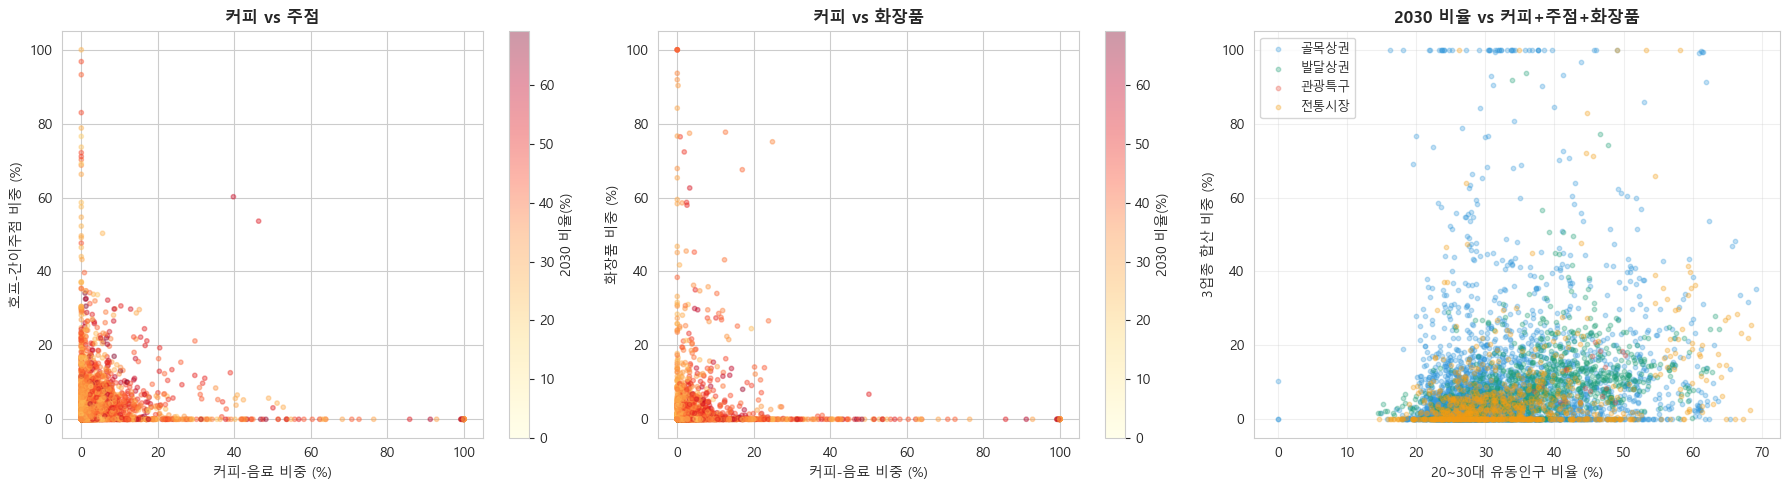

In [14]:
# %% 산점도: 커피 vs 주점 (2030 비율 색상)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
sample = merged_age.sample(n=min(5000, len(merged_age)), random_state=42)
 
# (1) 커피 vs 주점
ax1 = axes[0]
sc = ax1.scatter(sample['커피-음료_비중'], sample['호프-간이주점_비중'],
                 c=sample['2030_비율'], cmap='YlOrRd', alpha=0.4, s=10)
ax1.set_xlabel('커피-음료 비중 (%)')
ax1.set_ylabel('호프-간이주점 비중 (%)')
ax1.set_title('커피 vs 주점', fontweight='bold')
plt.colorbar(sc, ax=ax1, label='2030 비율(%)')
 
# (2) 커피 vs 화장품
ax2 = axes[1]
sc2 = ax2.scatter(sample['커피-음료_비중'], sample['화장품_비중'],
                  c=sample['2030_비율'], cmap='YlOrRd', alpha=0.4, s=10)
ax2.set_xlabel('커피-음료 비중 (%)')
ax2.set_ylabel('화장품 비중 (%)')
ax2.set_title('커피 vs 화장품', fontweight='bold')
plt.colorbar(sc2, ax=ax2, label='2030 비율(%)')
 
# (3) 2030 비율 vs 3업종 합
ax3 = axes[2]
색_map = {'골목상권':'#3498DB','발달상권':'#1D9E75','관광특구':'#E74C3C','전통시장':'#F39C12'}
for 구분 in 상권:
    sub = sample[sample['상권_구분_코드_명'] == 구분]
    ax3.scatter(sub['2030_비율'], sub['타겟3_비중'],
                alpha=0.3, s=10, color=색_map[구분], label=구분)
ax3.set_xlabel('20~30대 유동인구 비율 (%)')
ax3.set_ylabel('3업종 합산 비중 (%)')
ax3.set_title('2030 비율 vs 커피+주점+화장품', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)
 
plt.tight_layout()
plt.show()

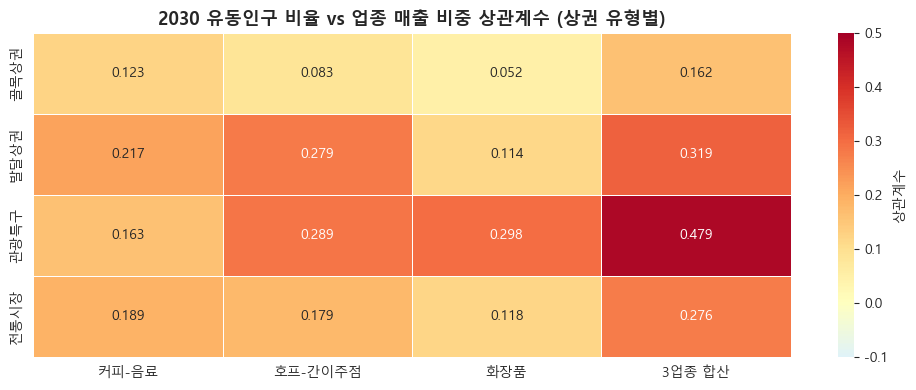

In [17]:
# %% 히트맵
corr_data = []
for 구분 in 상권:
    sub = merged_age[merged_age['상권_구분_코드_명'] == 구분]
    row = []
    for 업종 in 타겟업종 + ['타겟3']:
        col = f'{업종}_비중'
        c = sub[['2030_비율', col]].corr().iloc[0, 1]
        row.append(c)
    corr_data.append(row)
 
corr_df = pd.DataFrame(corr_data, index=상권, columns=['커피-음료', '호프-간이주점', '화장품', '3업종 합산'])
 
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='RdYlBu_r',
            center=0, vmin=-0.1, vmax=0.5, ax=ax,
            linewidths=0.5, cbar_kws={'label': '상관계수'})
ax.set_title('2030 유동인구 비율 vs 업종 매출 비중 상관계수 (상권 유형별)', fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()